## Skills Trend of Data Engineer in United States

In [2]:
# import libraries
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# clean data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [3]:
# filter only 'Data Egineer' & 'United States'
df_de_us = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'United States')].copy()

df_de_us.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '..."
11,Data Engineer,Data Engineer,"Colorado Springs, CO (+3 others)",via The Muse,Full-time,False,"Texas, United States",2023-11-03 13:06:51,False,True,United States,NaN,NaN,NaN,Philips,"[python, qlik]","{'analyst_tools': ['qlik'], 'programming': ['p..."
26,Data Engineer,Data Engineer,United States,via LinkedIn,Full-time,False,Georgia,2023-09-15 13:56:18,True,False,United States,NaN,NaN,NaN,Infinite Computer Solutions,NaN,NaN
27,Data Engineer,"Principal Data Engineer (Lead), Knowledge Grap...","San Francisco, CA",via LinkedIn,Full-time,False,Georgia,2023-02-18 13:31:24,False,False,United States,NaN,NaN,NaN,Altos Labs,"[python, r, java]","{'programming': ['python', 'r', 'java']}"


In [4]:
# add new column for 'month number'
df_de_us['job_posted_month'] = df_de_us['job_posted_date'].dt.month

df_de_us.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",7
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"[python, sql, gcp]","{'cloud': ['gcp'], 'programming': ['python', '...",11
11,Data Engineer,Data Engineer,"Colorado Springs, CO (+3 others)",via The Muse,Full-time,False,"Texas, United States",2023-11-03 13:06:51,False,True,United States,NaN,NaN,NaN,Philips,"[python, qlik]","{'analyst_tools': ['qlik'], 'programming': ['p...",11
26,Data Engineer,Data Engineer,United States,via LinkedIn,Full-time,False,Georgia,2023-09-15 13:56:18,True,False,United States,NaN,NaN,NaN,Infinite Computer Solutions,NaN,NaN,9
27,Data Engineer,"Principal Data Engineer (Lead), Knowledge Grap...","San Francisco, CA",via LinkedIn,Full-time,False,Georgia,2023-02-18 13:31:24,False,False,United States,NaN,NaN,NaN,Altos Labs,"[python, r, java]","{'programming': ['python', 'r', 'java']}",2


In [5]:
# explode the job_skills column
df_de_us_explode = df_de_us.explode('job_skills').copy()

df_de_us_explode.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,python,"{'cloud': ['aws'], 'libraries': ['tensorflow',...",7
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,c++,"{'cloud': ['aws'], 'libraries': ['tensorflow',...",7
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,java,"{'cloud': ['aws'], 'libraries': ['tensorflow',...",7
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,matlab,"{'cloud': ['aws'], 'libraries': ['tensorflow',...",7
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,aws,"{'cloud': ['aws'], 'libraries': ['tensorflow',...",7


In [6]:
# pivot it, and assign it to a new variable
df_de_us_pivot = df_de_us_explode.pivot_table(
    index='job_posted_month',
    columns='job_skills',
    aggfunc='size',
    fill_value=0                # NaN value would be 0
)

df_de_us_pivot

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,watson,webex,windows,wire,word,workfront,wrike,xamarin,yarn,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,347,0,45,20,2,42,0,0,2,5,...,0,0,43,2,68,0,0,0,9,5
2,398,1,58,25,1,26,0,3,5,7,...,5,1,50,0,92,0,0,0,18,14
3,421,0,55,20,2,36,2,2,3,3,...,4,0,43,4,86,0,0,0,10,4
4,390,2,46,58,0,41,1,0,4,3,...,5,0,45,1,50,0,0,0,8,5
5,435,0,57,75,0,53,0,3,3,2,...,2,0,61,3,71,0,0,1,14,3
6,411,0,84,28,0,55,0,0,4,5,...,1,0,65,1,55,0,0,0,12,9
7,362,7,71,28,0,38,0,0,5,7,...,0,4,63,2,59,1,0,0,11,8
8,452,2,69,33,1,41,1,5,2,4,...,2,0,66,2,65,0,0,0,13,8
9,389,0,46,19,1,62,0,0,1,3,...,0,3,65,1,73,0,0,0,13,8


In [7]:
# add row of 'total'
df_de_us_pivot.loc['total'] = df_de_us_pivot.sum()

df_de_us_pivot

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,watson,webex,windows,wire,word,workfront,wrike,xamarin,yarn,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,347,0,45,20,2,42,0,0,2,5,...,0,0,43,2,68,0,0,0,9,5
2,398,1,58,25,1,26,0,3,5,7,...,5,1,50,0,92,0,0,0,18,14
3,421,0,55,20,2,36,2,2,3,3,...,4,0,43,4,86,0,0,0,10,4
4,390,2,46,58,0,41,1,0,4,3,...,5,0,45,1,50,0,0,0,8,5
5,435,0,57,75,0,53,0,3,3,2,...,2,0,61,3,71,0,0,1,14,3
6,411,0,84,28,0,55,0,0,4,5,...,1,0,65,1,55,0,0,0,12,9
7,362,7,71,28,0,38,0,0,5,7,...,0,4,63,2,59,1,0,0,11,8
8,452,2,69,33,1,41,1,5,2,4,...,2,0,66,2,65,0,0,0,13,8
9,389,0,46,19,1,62,0,0,1,3,...,0,3,65,1,73,0,0,0,13,8


In [8]:
# sort the total, and then assign it to a variable
df_pivot = df_de_us_pivot[df_de_us_pivot.loc['total'].sort_values(ascending=False).index]

df_pivot

job_skills,sql,python,aws,azure,spark,java,snowflake,hadoop,kafka,scala,...,lisp,fastify,qt,powerbi,mlpack,sqlserver,svelte,workfront,xamarin,wrike
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,1826,1745,1119,841,916,695,592,515,547,517,...,0,0,0,0,0,0,0,0,0,0
2,2109,2043,1415,965,1063,829,763,645,647,597,...,1,0,0,0,0,0,0,0,0,0
3,2204,2126,1472,1023,1038,791,704,640,605,587,...,0,0,0,0,0,0,0,0,0,0
4,1914,1868,1222,937,878,682,676,498,514,534,...,0,0,0,0,0,0,0,0,0,0
5,2077,2023,1252,990,952,730,681,529,491,509,...,0,0,0,0,0,0,0,0,1,0
6,2048,1882,1260,947,955,686,668,516,495,459,...,0,0,0,0,0,0,0,0,0,0
7,1789,1689,1166,794,821,615,624,483,448,461,...,1,0,1,0,0,0,0,1,0,0
8,2246,2155,1388,1003,1006,754,749,594,565,557,...,0,0,0,0,0,1,1,0,0,0
9,2090,1934,1267,960,941,671,700,479,500,483,...,0,0,0,1,0,0,0,0,0,0


In [9]:
# already sort out variable, then drop the total row, cause we need to make a plot
df_pivot = df_pivot.drop('total')

df_pivot

job_skills,sql,python,aws,azure,spark,java,snowflake,hadoop,kafka,scala,...,lisp,fastify,qt,powerbi,mlpack,sqlserver,svelte,workfront,xamarin,wrike
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,1826,1745,1119,841,916,695,592,515,547,517,...,0,0,0,0,0,0,0,0,0,0
2,2109,2043,1415,965,1063,829,763,645,647,597,...,1,0,0,0,0,0,0,0,0,0
3,2204,2126,1472,1023,1038,791,704,640,605,587,...,0,0,0,0,0,0,0,0,0,0
4,1914,1868,1222,937,878,682,676,498,514,534,...,0,0,0,0,0,0,0,0,0,0
5,2077,2023,1252,990,952,730,681,529,491,509,...,0,0,0,0,0,0,0,0,1,0
6,2048,1882,1260,947,955,686,668,516,495,459,...,0,0,0,0,0,0,0,0,0,0
7,1789,1689,1166,794,821,615,624,483,448,461,...,1,0,1,0,0,0,0,1,0,0
8,2246,2155,1388,1003,1006,754,749,594,565,557,...,0,0,0,0,0,1,1,0,0,0
9,2090,1934,1267,960,941,671,700,479,500,483,...,0,0,0,1,0,0,0,0,0,0


In [10]:
# we need to change the count to pct %
# hence, we need the totals of skill appears monthly
df_de_totals = df_de_us.groupby('job_posted_month').size()

df_de_totals

job_posted_month
1     2655
2     3060
3     3183
4     2801
5     2976
6     2893
7     2570
8     3269
9     3224
10    3015
11    2793
12    2641
dtype: int64

In [11]:
# convert to pcct% using .div(), assign it to var
df_de_pct = df_pivot.div(df_de_totals / 100, axis=0)

df_de_pct

job_skills,sql,python,aws,azure,spark,java,snowflake,hadoop,kafka,scala,...,lisp,fastify,qt,powerbi,mlpack,sqlserver,svelte,workfront,xamarin,wrike
job_posted_month,,,,,,,,,,,,,,,,,,,,,
1,68.775895,65.725047,42.146893,31.676083,34.500942,26.177024,22.297552,19.397363,20.602637,19.472693,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
2,68.921569,66.764706,46.241830,31.535948,34.738562,27.091503,24.934641,21.078431,21.143791,19.509804,...,0.032680,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
3,69.242853,66.792334,46.245680,32.139491,32.610745,24.850770,22.117499,20.106817,19.007226,18.441722,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
4,68.332738,66.690468,43.627276,33.452338,31.345948,24.348447,24.134238,17.779365,18.350589,19.064620,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
5,69.791667,67.977151,42.069892,33.266129,31.989247,24.529570,22.883065,17.775538,16.498656,17.103495,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.033602,0.000000
6,70.791566,65.053578,43.553405,32.734186,33.010716,23.712409,23.090218,17.836156,17.110266,15.865883,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
7,69.610895,65.719844,45.369650,30.894942,31.945525,23.929961,24.280156,18.793774,17.431907,17.937743,...,0.038911,0.000000,0.038911,0.000000,0.000000,0.00000,0.00000,0.038911,0.000000,0.000000
8,68.706026,65.922300,42.459468,30.682166,30.773937,23.065158,22.912206,18.170694,17.283573,17.038850,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.03059,0.03059,0.000000,0.000000,0.000000
9,64.826303,59.987593,39.299007,29.776675,29.187345,20.812655,21.712159,14.857320,15.508685,14.981390,...,0.000000,0.000000,0.000000,0.031017,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000


In [12]:
# change the month number into month abv. ex(jan, feb,...)
df_de_pct = df_de_pct.reset_index()

df_de_pct['job_posted_month'] = df_de_pct['job_posted_month'].apply(
    lambda x: pd.to_datetime(x, format='%m').strftime('%b')
)

df_de_pct = df_de_pct.set_index('job_posted_month')

df_de_pct

job_skills,sql,python,aws,azure,spark,java,snowflake,hadoop,kafka,scala,...,lisp,fastify,qt,powerbi,mlpack,sqlserver,svelte,workfront,xamarin,wrike
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,68.775895,65.725047,42.146893,31.676083,34.500942,26.177024,22.297552,19.397363,20.602637,19.472693,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
Feb,68.921569,66.764706,46.241830,31.535948,34.738562,27.091503,24.934641,21.078431,21.143791,19.509804,...,0.032680,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
Mar,69.242853,66.792334,46.245680,32.139491,32.610745,24.850770,22.117499,20.106817,19.007226,18.441722,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
Apr,68.332738,66.690468,43.627276,33.452338,31.345948,24.348447,24.134238,17.779365,18.350589,19.064620,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
May,69.791667,67.977151,42.069892,33.266129,31.989247,24.529570,22.883065,17.775538,16.498656,17.103495,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.033602,0.000000
Jun,70.791566,65.053578,43.553405,32.734186,33.010716,23.712409,23.090218,17.836156,17.110266,15.865883,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
Jul,69.610895,65.719844,45.369650,30.894942,31.945525,23.929961,24.280156,18.793774,17.431907,17.937743,...,0.038911,0.000000,0.038911,0.000000,0.000000,0.00000,0.00000,0.038911,0.000000,0.000000
Aug,68.706026,65.922300,42.459468,30.682166,30.773937,23.065158,22.912206,18.170694,17.283573,17.038850,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.03059,0.03059,0.000000,0.000000,0.000000
Sep,64.826303,59.987593,39.299007,29.776675,29.187345,20.812655,21.712159,14.857320,15.508685,14.981390,...,0.000000,0.000000,0.000000,0.031017,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000


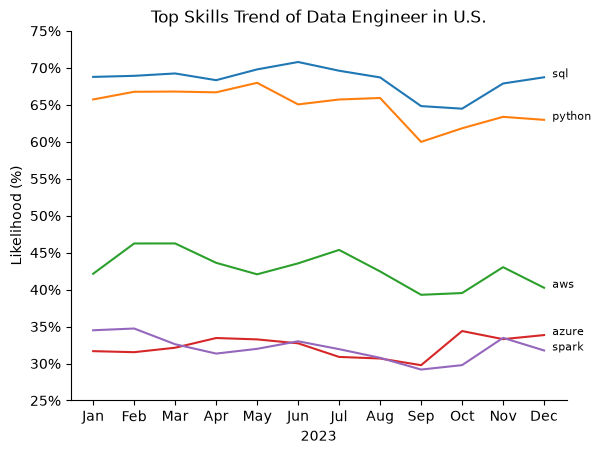

In [15]:
# Plot skill demand trends
# Filter the top 5 skills

df_plot = df_de_pct.iloc[:, :5]

sns.lineplot(
    data=df_plot,
    dashes=False,
    palette='tab10'
)

sns.despine()

plt.title('Top Skills Trend of Data Engineer in U.S.')
plt.xlabel('2023')
plt.ylabel('Likelihood (%)')
plt.ylim(25, 75)
plt.yticks(np.arange(25, 76, 5))
plt.legend().set_visible(False)

# Format y-axis as percentages
from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Add skill names to the end of each line
for i in range(5):
    plt.text(
        11.2,
        df_plot.iloc[-1, i],
        df_plot.columns[i],
        fontsize=8
    )

plt.show()